# **Mission 3: Exploratory Data Analysis (EDA) with the Sales Dataset using Pandas and d Matplotlib/Seaborn**

### **Objective:**

The goal of this assignment is to help you apply your knowledge of Python for basic operations, Pandas for data manipulation, and Matplotlib/Seaborn for visualizations. You'll be working with a real-world dataset, and your tasks will include loading the data, performing EDA, and visualising the results.

###  **Dataset**

The dataset represents transaction data from a retail business, specifically sales data for products sold in various stores. It contains multiple tables that provide insights into sales, invoices, and products. Let’s break down the tables and what they represent:

#### Sales Table:

InvoiceNo: The unique identifier for each invoice (or transaction).

StockCode: A unique identifier for each product.

Quantity: The number of units sold in each transaction.

UnitPrice: The price per unit of the product.

InvoiceDate: The date when the transaction occurred.

#### Invoice Table:

InvoiceNo: The same unique identifier for each invoice, linking the sales data with the invoice details.

Country: The country where the sale was made.

#### Product Table:

StockCode: A unique identifier for each product.

Description: The name or description of the product.

Product_Category: The category the product belongs to (e.g., "Gift", "Sign", "Mug").



You will need to merge them and perform the following tasks step by step.


### Task 1: Load the Excel File
#### Objective: Import the data from the provided Excel file into Python using Pandas.

Instructions:

1. Upload the provided excel file into Fabric environment
2. Read each sheet of the excel file as a separate dataframe. 
3. Name the dataframe for sales as df_sales, the dataframe for invoice as df_invoice and the dataframe for product as df_product
4. Display the first few rows of each DataFrame to understand its structure.



In [2]:
import pandas as pd

df_sales = pd.read_excel(f"{notebookutils.nbResPath}/builtin/online_sales_retailer.xlsx", sheet_name= 'Sales')
df_invoice = pd.read_excel(f"{notebookutils.nbResPath}/builtin/online_sales_retailer.xlsx", sheet_name= 'Invoice')
df_product = pd.read_excel(f"{notebookutils.nbResPath}/builtin/online_sales_retailer.xlsx", sheet_name= 'Product')

# Display the first few rows of each DataFrame
display(df_sales.head())
display(df_invoice.head())
display(df_product.head())

### Task 2: Basic Python and Pandas Operations
#### Objective: Perform basic Python and Pandas operations to manipulate the data.

<mark>Instructions:</mark>

1. Check for missing values in the Sales DataFrame.

2. Replace any NaN values in the Sales and UnitPrice columns with 0.

3. Calculate basic descriptive statistics for the Quantity and UnitPrice columns (mean, median, mode, standard deviation).

In [3]:
# Check for missing values in the Sales DataFrame
missing_values = df_sales.isnull()

# Display only rows with null values
rows_with_nulls = df_sales[missing_values.any(axis=1)]

# Display the rows with null values
display(rows_with_nulls)

In [4]:
# Replace missing values in 'Sales' columns with 0

df_sales['InvoiceNo'].fillna(0, inplace=True)
df_sales['StockCode'].fillna(0, inplace=True)
df_sales['Quantity'].fillna(0, inplace=True)
df_sales['UnitPrice'].fillna(0, inplace=True)
df_sales['InvoiceDate'].fillna(0, inplace=True)

display(df_sales.head())

In [5]:
## Calculate basic descriptive statistics for the Quantity and UnitPrice columns

mean_quantity = df_sales['Quantity'].mean()
median_quantity = df_sales['Quantity'].median()
std_quantity = df_sales['Quantity'].std()

mean_unitprice = df_sales['UnitPrice'].mean()
median_unitprice = df_sales['UnitPrice'].median()
std_unitprice = df_sales['UnitPrice'].std()

# Display the results

print(f"Quantity - Mean: {mean_quantity}, Median: {median_quantity}, Std Dev: {std_quantity}")
print(f"UnitPrice - Mean: {mean_unitprice}, Median - Sales: {median_unitprice}, Std Dev Sales: {std_unitprice}")

Quantity - Mean: 13.610961009642518, Median: 6.0, Std Dev: 261.57756533193884
UnitPrice - Mean: 3.0835027678710816, Median - Sales: 1.95, Std Dev Sales: 5.17765256537552


### Task 3: Merging DataFrames
#### Objective: Merge the Sales, Invoice, and Product tables based on common keys to perform a comprehensive analysis.

Instructions:

1. Merge the Sales DataFrame with the Invoice DataFrame on InvoiceNo.

2. Merge the result with the Product DataFrame on StockCode

In [6]:
# Merge Sales and Payments DataFrames on 'Payment'
df_combined = pd.merge(df_sales, df_invoice, on='InvoiceNo')

# Display the first few rows of the merged DataFrame
display(df_combined.head())

In [7]:
# Merge Sales + Invoice with Product on StockCode
df_final = pd.merge( df_combined,df_product,on="StockCode",how="left")



# Display the result
display(df_final.head())

## Task 4: Exploratory Data Analysis (EDA)
### Objective: Conduct EDA by analysing the data, identifying patterns, trends, and outliers.

Instructions:

Use describe() to calculate summary statistics for numeric columns.

Perform basic filtering, such as filtering out sales with Quantity equal to 0.

Check for outliers in the Sales column by using a scatter plot.

In [8]:
# Create the Sales column
df_final['Sales'] = df_final['Quantity'] * df_final['UnitPrice']
display(df_final.head(5))

# Use describe() to calculate summary statistics for numeric columns.

summary = df_final[['Quantity', 'UnitPrice','Sales']].describe()

# Rename statistics 
summary.index = [
    'Count',
    'Mean',
    'Standard Deviation',
    'Minimum',
    '25th Percentile',
    'Median (50%)',
    '75th Percentile',
    'Maximum'
]

# Transpose the table
summary = summary.T

# Display the result
display(summary)

In [9]:
##Importing seaborn matplotlib
!pip install seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 12.6 MB/s eta 0:00:00


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out rows where Quantity is 0
df_filtered = df_final[df_final['Quantity'] > 0]
df_filtered['month_year'] = df_filtered['InvoiceDate'].dt.strftime('%m-%Y')
display(df_filtered.head(10))

total_sales = df_filtered['Sales'].sum()
print("Total Sales:", total_sales)



Total Sales: 1925451.1


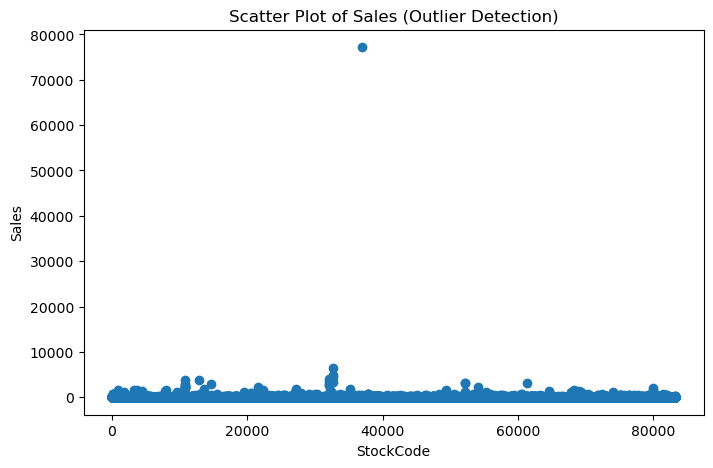

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df_filtered.index, df_filtered['Sales'])
plt.title('Scatter Plot of Sales (Outlier Detection)')
plt.xlabel('StockCode')
plt.ylabel('Sales')
plt.show()

## Task 5: Data Visualisation – Scatter Plot, Histogram, and Line Chart
### Objective: Create scatter plots, histograms, and line charts to better understand the data.

Instructions:

Use a scatter plot to examine the relationship between Quantity and Sales.

Use a histogram to visualise the distribution of the Sales column.

Use a line chart to show the trend of Sales over time.


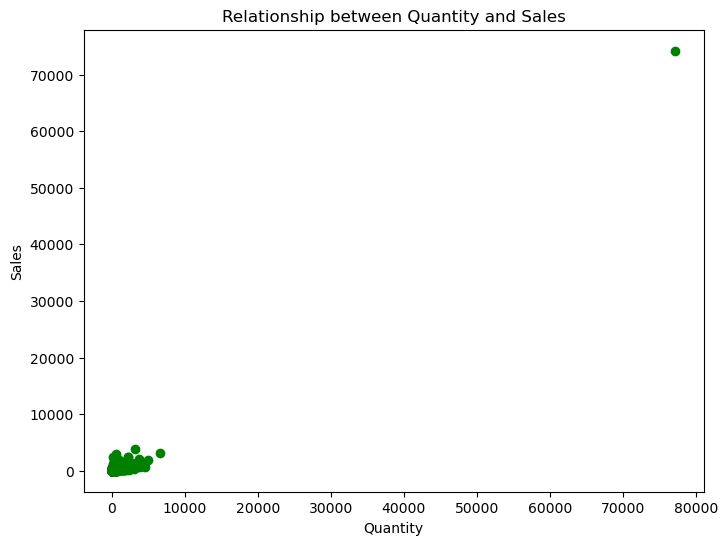

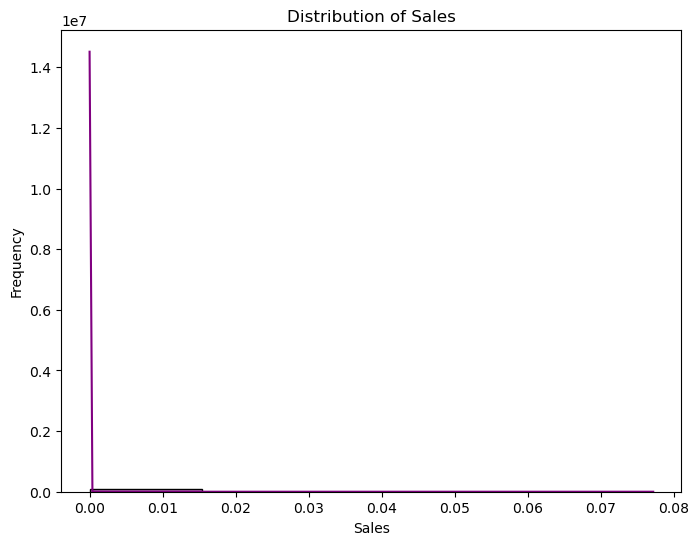

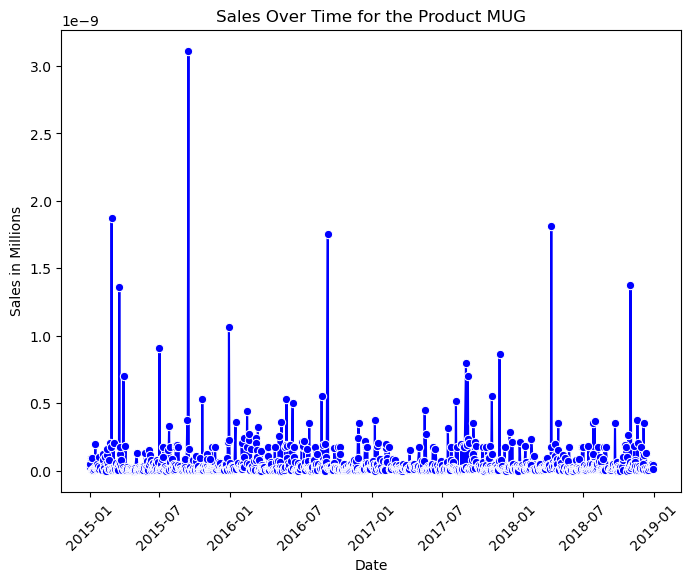

In [12]:
## Code Task 5 here
import matplotlib.pyplot as plt
# Scatter plot to visualise the relationship between Quantity and Sales
plt.figure(figsize=(8, 6))
plt.scatter(x = 'Sales', y = 'Quantity', data = df_filtered, color = 'green')
plt.xlabel('Quantity')
plt.ylabel('Sales')
plt.title('Relationship between Quantity and Sales')
plt.show()

# Histogram to visualise the distribution of Sales
plt.figure(figsize=(8, 6))
df_filtered['Sales'] = df_filtered['Sales']/1000000
sns.histplot(df_filtered['Sales'], bins=5, color='purple', kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

# line chart to show the trend of Sales over time.

plt.figure(figsize=(8, 6))
sales_product = df_filtered[df_filtered['Product_Category'] == 'MUG']
sales_product_s = sales_product.groupby('InvoiceDate')['Sales'].sum().reset_index()
sales_product_s['Sales'] = sales_product_s['Sales']/1000000

sns.lineplot(x='InvoiceDate', y='Sales', data= sales_product_s, marker='o', color='blue')
plt.title('Sales Over Time for the Product MUG')
plt.xlabel('Date')
plt.ylabel('Sales in Millions')
plt.xticks(rotation=45)
plt.show()

## Task 6: Correlation and Data Insights
### Objective: Identify the relationship between different numerical columns in the dataset.

Instructions:

Calculate the correlation between Quantity and Sales.

Visualise the correlation matrix using a heatmap.

Correlation between Quantity and Sales: 0.9786
Correlation Matrix:
           InvoiceNo  StockCode  Quantity  UnitPrice     Sales
InvoiceNo   1.000000  -0.014377  0.000694   0.001931 -0.001478
StockCode  -0.014377   1.000000  0.001051  -0.019019  0.002768
Quantity    0.000694   0.001051  1.000000  -0.013917  0.978609
UnitPrice   0.001931  -0.019019 -0.013917   1.000000  0.027060
Sales      -0.001478   0.002768  0.978609   0.027060  1.000000


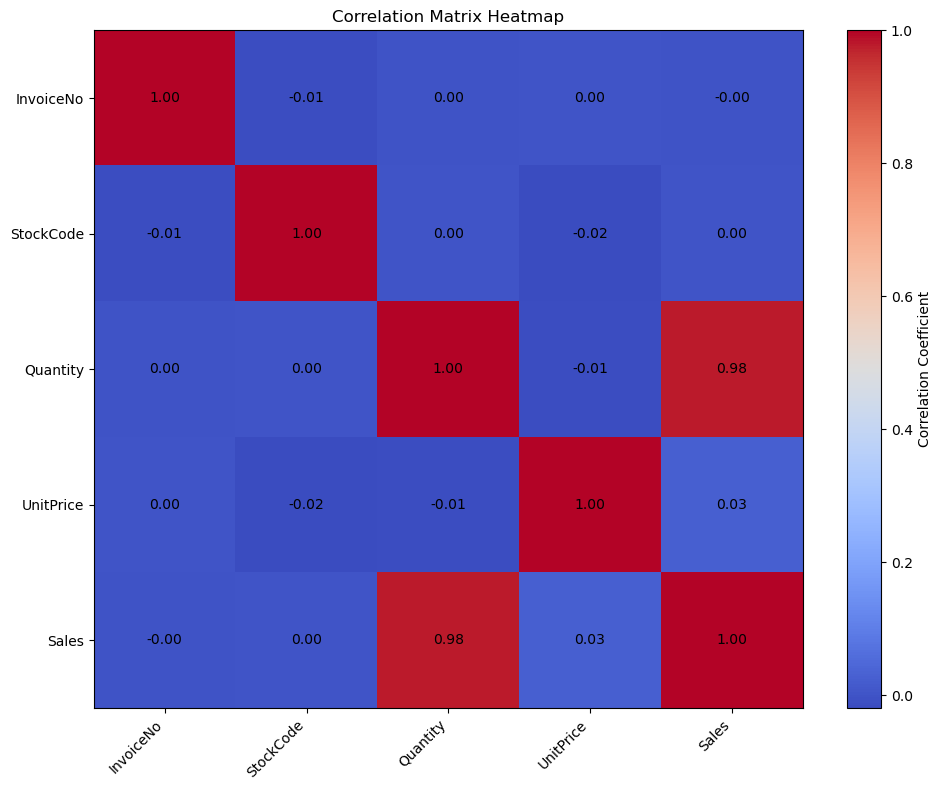

In [13]:
## First we need to Calculate the correlation between Quantity and Sales

correlation = df_filtered['Quantity'].corr(df_filtered['Sales'])
print(f"Correlation between Quantity and Sales: {correlation:.4f}")

### And we will visualise this correlation by using a heatmap

numeric_cols = df_filtered.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df_filtered[numeric_cols].corr()

print("Correlation Matrix:")
print(correlation_matrix)

###Creating The Heatmap

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest', aspect='auto')
plt.colorbar(label='Correlation Coefficient')

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

### And we need to add the correlatuon values as text

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
        ha='center', va='center', color='black', fontsize=10)

plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()        


## Task 7: Grouping and Aggregating
### Objective: Perform grouping and aggregation operations to summarise the data.

Instructions:

GroupBy operation: Group by Product_Category and calculate the total Sales per category.

Create a Pivot Table to show Sales by Country and Product_Category.

In [14]:
## We want to Group by the Product_Category column and then calcualte the total Sales per category.

category_sales = df_final.groupby('Product_Category')['Sales'].sum().sort_values(ascending=False)

print("Total Sales by Product Category")
print(category_sales)

Total Sales by Product Category
Product_Category
Uncategorized    191282.70
CHRISTMAS         88028.94
CANDLE            83853.88
GLASS             78757.36
MUG               70058.81
                   ...    
SHIRT                37.50
EARRING              34.00
PLANTER              21.95
BURNER                4.75
ERASERS               3.75
Name: Sales, Length: 170, dtype: float64


In [16]:
### And now we'll put that into a Pivot Table using Country and the Product Category

pivot_table= df_final.pivot_table(
    values='Sales',
    index='Country',
    columns='Product_Category',
    aggfunc='sum',
    fill_value=0
)

print("Pivot Table: Sales by Country and Product Category")
print(pivot_table)

Pivot Table: Sales by Country and Product Category
Product_Category        APRON  BACKPACK   BADGES       BAG  BALLOONS    BAND  \
Country                                                                        
AUS                      0.00       0.0     0.00     15.60      0.00    0.00   
Australia                0.00       0.0     0.00    188.56     10.08    0.00   
Austria                  0.00       0.0     0.00     58.18      0.00    0.00   
Bahrain                  0.00       0.0     0.00      0.00      0.00    0.00   
Belgium                 45.27       0.0    17.85    206.74      0.00    0.00   
Brazil                   0.00       0.0     0.00      0.00      0.00    0.00   
Canada                   0.00       0.0     0.00      0.00      0.00    0.00   
Channel Islands          5.04       0.0     0.00     80.75      5.95    0.00   
Cyprus                   0.00       0.0     0.00      0.00      0.00    0.00   
Czech Republic           0.00       0.0     0.00      0.00      0.00 

## Submission Guidelines:
Submit the Python notebook with all the tasks and visualisations.

Ensure that each task is clearly explained and that all steps are followed.

Include markdown explanations where necessary to explain your thought process.

Good work on the code but I dont see any insights from the charts or any explanation for findings on the data. Jose